# Analisi Prenotazioni Hotel

Dataset: Hotel Booking Demand



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns




df = pd.read_csv("Clean_Data_PBI.csv", sep = ';')

In [8]:
df.head()


,ID,hotel,is_canceled,is_canceled_TEXT,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,Custom,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,Resort Hotel,0,No,342,2015,July,27,1,2015-07-01,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,2,Resort Hotel,0,No,737,2015,July,27,1,2015-07-01,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,3,Resort Hotel,0,No,7,2015,July,27,1,2015-07-01,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,4,Resort Hotel,0,No,13,2015,July,27,1,2015-07-01,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,5,Resort Hotel,0,No,14,2015,July,27,1,2015-07-01,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Analisi delle cancellazioni 

In [9]:
print(f"Totale prenotazioni : {len(df):,}")
print(f"Totale cancellazioni: {df['is_canceled'].sum():,}")



print(f"Percentuale totale di cancellazione: {df['is_canceled'].mean() * 100:.1f}%")

Totale prenotazioni : 119,386
Totale cancellazioni: 44,220
Percentuale totale di cancellazione: 37.0%


In [10]:
cancel_rate = df.groupby('hotel')['is_canceled'].mean() * 100 
print("Percentuale di cancellazione x tipologia di Hotel:")
for hotel, rate in cancel_rate.items(): 
    print(f"  {hotel}: {rate:.1f}%") 





Percentuale di cancellazione x tipologia di Hotel:
  City Hotel: 41.7%
  Resort Hotel: 27.8%


In [11]:
cancel_rate = df.groupby('customer_type')['is_canceled'].mean() * 100
print("Percentuale di cancellazione x tipologia di clientela:")
for tipo, rate in cancel_rate.items():
    print(f"  {tipo}: {rate:.1f}%")

Percentuale di cancellazione x tipologia di clientela:
  Contract: 31.0%
  Group: 10.2%
  Transient: 40.7%
  Transient-Party: 25.4%


# Periodo con maggior e minor numero di prenotazioni per Hotel

In [12]:
df_active = df[df['is_canceled'] == 0 ]

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

occupancy = df_active.groupby(['hotel', 'arrival_date_month']).size().reset_index(name='prenotazioni')

tabella = occupancy.pivot(index='arrival_date_month', columns='hotel', values='prenotazioni')
tabella = tabella.reindex(month_order)
print("N. Prenotazioni x Mese:")
print(tabella.to_string())





print(" Mese con più prenotazioni City Hotel vs Resort Hotel:")
print(f" City Hotel   : {tabella['City Hotel'].idxmax()} ({tabella['City Hotel'].max():,} prenotazioni)")
print(f"Resort Hotel : {tabella['Resort Hotel'].idxmax()} ({tabella['Resort Hotel'].max():,} prenotazioni)")


print(" Mese con meno prenotazioni City Hotel vs Resort Hotel:")
print(f" City Hotel   : {tabella['City Hotel'].idxmin()} ({tabella['City Hotel'].min():,} prenotazioni)")
print(f"Resort Hotel : {tabella['Resort Hotel'].idxmin()} ({tabella['Resort Hotel'].min():,} prenotazioni)")


N. Prenotazioni x Mese:
hotel               City Hotel  Resort Hotel
arrival_date_month                          
January                   2254          1868
February                  3064          2308
March                     4072          2573
April                     4015          2550
May                       4579          2535
June                      4366          2038
July                      4782          3137
August                    5381          3257
September                 4290          2102
October                   4337          2577
November                  2696          1976
December                  2392          2017
 Mese con più prenotazioni City Hotel vs Resort Hotel:
 City Hotel   : August (5,381 prenotazioni)
Resort Hotel : August (3,257 prenotazioni)
 Mese con meno prenotazioni City Hotel vs Resort Hotel:
 City Hotel   : January (2,254 prenotazioni)
Resort Hotel : January (1,868 prenotazioni)


<Figure size 1200x600 with 0 Axes>

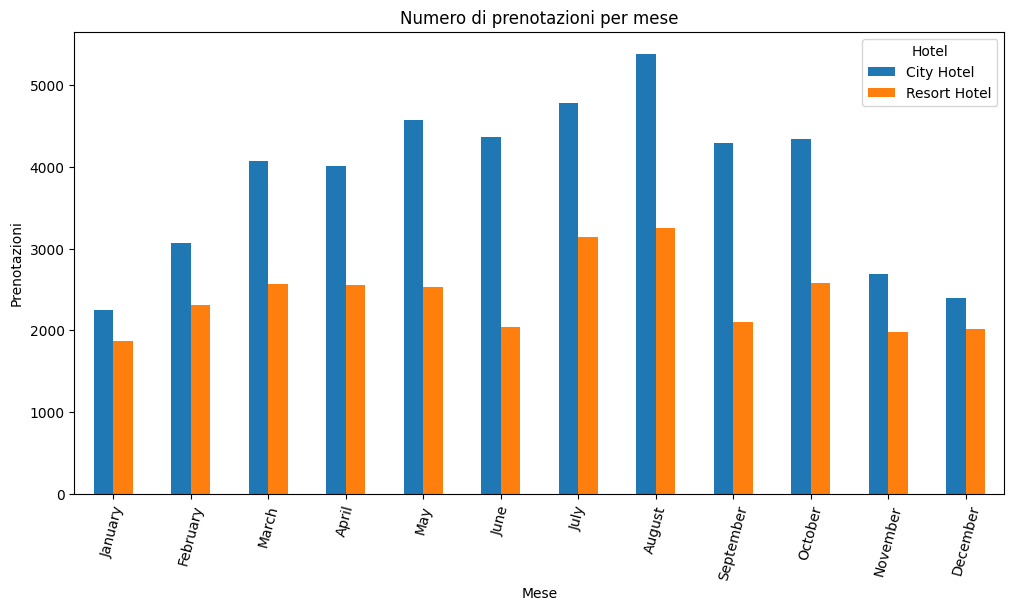

In [13]:
plt.figure(figsize=(12,6))

tabella.plot(kind='bar', figsize=(12,6))

plt.title('Numero di prenotazioni per mese')
plt.xlabel('Mese')
plt.ylabel('Prenotazioni')
plt.xticks(rotation=75)
plt.legend(title='Hotel')

plt.show()



# Durata media soggiorno

In [14]:
df['durata_totale'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df_active = df[df['is_canceled'] == 0]


print("Soggiorno Medio")
for hotel in ['City Hotel', 'Resort Hotel']:
    d = df_active[df_active['hotel'] == hotel]['durata_totale']
    print(f"{hotel}:")
    print(f"    Media soggiorno : {d.mean():.1f} notti")


  

Soggiorno Medio
City Hotel:
    Media soggiorno : 2.9 notti
Resort Hotel:
    Media soggiorno : 4.1 notti


# Analisi ADR medio in base al mese e alla tipologia di Hotel 

In [15]:
mesi = ['January','February','March','April','May','June',
        'July','August','September','October','November','December']

adr_mensile = df.groupby(['arrival_date_month', 'hotel'])['adr'].mean().round(2).unstack()
adr_mensile = adr_mensile.reindex(mesi)
print(adr_mensile)

hotel               City Hotel  Resort Hotel
arrival_date_month                          
January                  82.63         49.46
February                 85.09         55.17
March                    92.64         57.52
April                   111.25         77.85
May                     121.64         78.76
June                    119.07        110.44
July                    110.73        155.18
August                  114.72        186.79
September               110.00         93.25
October                  99.97         62.10
November                 88.07         48.27
December                 88.83         68.98


# Paesi con più prenotazioni 

In [16]:
country_data = df_active.groupby(['hotel', 'country']).size().reset_index(name='prenotazioni')

top_city = (country_data[country_data['hotel'] == 'City Hotel'].sort_values('prenotazioni', ascending=False))

top_resort = (country_data[country_data['hotel'] == 'Resort Hotel'].sort_values('prenotazioni',ascending=False))

print( "Paese con più prenotazioni:")
for hotel, data in [(' City Hotel', top_city), ('  Resort Hotel', top_resort)]:
    primo = data.iloc[0]
    print(f"  {hotel}: {primo['country']} ({primo['prenotazioni']:,} prenotazioni)")
    print ("PRT = Portogallo")



Paese con più prenotazioni:
   City Hotel: PRT (10,879 prenotazioni)
PRT = Portogallo
    Resort Hotel: PRT (10,192 prenotazioni)
PRT = Portogallo


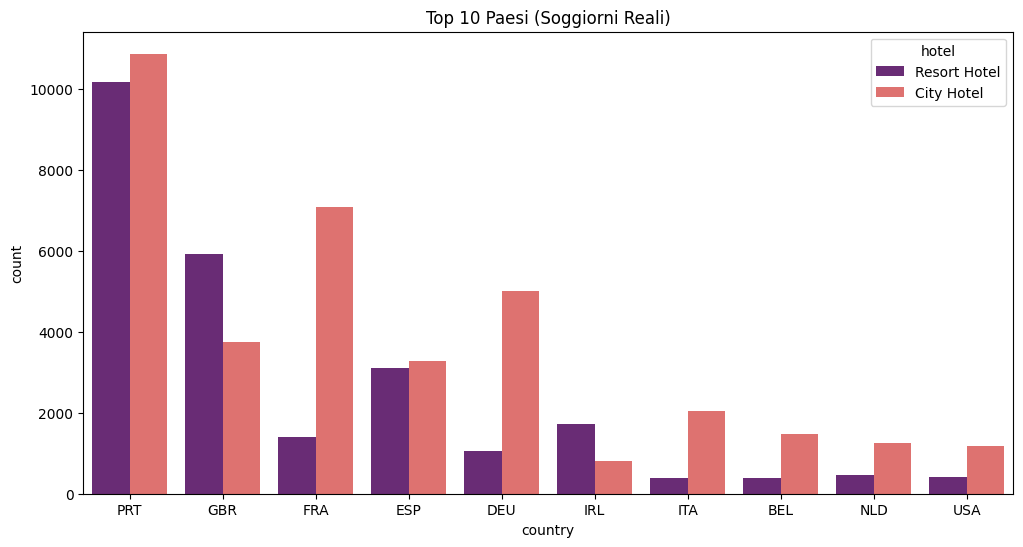

In [ ]:
df_active = df[df['is_canceled'] == 0]

top10 = df_active['country'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_active[df_active['country'].isin(top10)], 
    x='country', 
    hue='hotel', 
    palette='magma',
    order=top10
)

plt.title('Top 10 Paesi (Soggiorni Reali)')
plt.show()